# PatchCore + DINOv2 with Lightweight Adapter | Final Version (Improve Result)
## Comparative Analysis of Vision Foundation Models for Few-Shot Industrial Anomaly Detection
**Author:** Phumapiwat Chanyuthagorn | RIT MS in Artificial Intelligence | Spring 2026

### Key Insight:
Direct fine-tuning of DINOv2 (86M params) on 209 images causes over-adaptation.
A **lightweight adapter** (~1.18M params) placed after frozen DINOv2 features is small enough
to be trained meaningfully on limited industrial data without destroying pretrained representations.

### Architecture:
```
Image -> Frozen DINOv2 Block 12 -> [768-dim patch features] -> Adapter MLP -> [768-dim adapted features] -> PatchCore
```

### Adapter Design:
- Input: 768-dim (DINOv2 Block 12 output)
- Hidden: 384-dim (bottleneck for compression)
- Output: 768-dim (same dimensionality, plugs into PatchCore)
- Parameters: ~1.18M (vs 21M for backbone fine-tuning)
- Residual connection: output = adapter(x) + x (preserves original features)

### Training Objective:
Feature compactness with variance preservation:
- Pull normal features toward their center (compactness)
- But prevent collapse by preserving feature variance (regularization)
- This was the failure mode of our previous compactness attempt -- it collapsed features.
  The residual connection + variance term prevent that.

### Comparison:
1. ResNet-50 (frozen) -- baseline
2. DINOv2 Frozen Block 12 -- best frozen VFM
3. DINOv2 + Adapter (5ep) -- light adaptation
4. DINOv2 + Adapter (20ep) -- stronger adaptation

In [1]:
# -- CELL 1 : Install --------------------------------------------------------------
!pip install anomalib==1.1.0 timm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.5/786.5 kB 27.5 MB/s eta 0:00:00


In [2]:
# -- CELL 2 : Dataset setup --------------------------------------------------------
import os
!mkdir -p /content/datasets/

In [3]:
for zipname in ["bottle", "cable", "hazelnut", "leather", "tile"]:
    for path in [f"/content/{zipname}.zip", f"/content/{zipname}"]:
        if os.path.exists(path):
            os.system(f"unzip -qo {path} -d /content/datasets/")
            print(f"  Unzipped: {zipname}"); break
    else:
        print(f"  Skipped: {zipname}")

print("\nDataset:")
for cat in sorted(os.listdir("/content/datasets/")):
    p = f"/content/datasets/{cat}"
    if os.path.isdir(p):
        for split in ['train','test']:
            sp = os.path.join(p, split)
            if os.path.exists(sp):
                n = sum(len(os.listdir(os.path.join(sp,s))) for s in os.listdir(sp) if os.path.isdir(os.path.join(sp,s)))
                print(f"  {cat}/{split}: {n}")

  Unzipped: bottle
  Unzipped: cable
  Unzipped: hazelnut
  Unzipped: leather
  Unzipped: tile

Dataset:
  bottle/train: 209
  bottle/test: 83
  cable/train: 224
  cable/test: 150
  hazelnut/train: 391
  hazelnut/test: 110
  leather/train: 245
  leather/test: 124
  tile/train: 230
  tile/test: 117


In [4]:
# -- CELL 3 : Imports and config ----------------------------------------------------
import random, time, warnings, os, json, datetime, gc
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import roc_auc_score
from PIL import Image

DATASET_ROOT = Path("/content/datasets")
CKPT_DIR = Path("/content/checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR = Path("/content/logs"); LOG_DIR.mkdir(exist_ok=True)
FT_DIR = Path("/content/finetuned_models"); FT_DIR.mkdir(exist_ok=True)

CATEGORIES = [d.name for d in sorted(DATASET_ROOT.iterdir())
              if d.is_dir() and (d/"train"/"good").exists()]
print(f"Categories: {CATEGORIES}")

SHOT_COUNTS = [1, 5, 10, -1]
IMAGE_SIZE = 224; BATCH_SIZE = 32; SEED = 42; GRID_SIZE = 16

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")

def get_subsample_ratio(n_shot):
    if n_shot is None:   return 0.01
    elif n_shot <= 1:    return 1.0
    elif n_shot <= 5:    return 0.25
    elif n_shot <= 10:   return 0.1
    else:                return 0.05

Categories: ['bottle', 'cable', 'hazelnut', 'leather', 'tile']
Device: cuda
GPU: Tesla T4


In [5]:
# -- CELL 4 : Dataset --------------------------------------------------------------
class MVTecFewShotDataset(Dataset):
    def __init__(self, root, split="train", n_shot=None, image_size=224, seed=42):
        self.root = Path(root); self.split = split; self.image_size = image_size
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)), transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
        self.samples = []; self._load(n_shot, seed)

    def _load(self, n_shot, seed):
        if self.split == "train":
            d = self.root/"train"/"good"
            paths = sorted(d.glob("*.png")) + sorted(d.glob("*.jpg"))
            if n_shot is not None:
                paths = random.Random(seed).sample(paths, min(n_shot, len(paths)))
            self.samples = [(p,0,None) for p in paths]
        else:
            for dt in sorted((self.root/"test").iterdir()):
                if not dt.is_dir(): continue
                label = 0 if dt.name == "good" else 1
                for p in sorted(dt.glob("*.png")) + sorted(dt.glob("*.jpg")):
                    mask = self.root/"ground_truth"/dt.name/(p.stem+"_mask.png")
                    self.samples.append((p, label, mask if label and mask.exists() else None))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        p, label, mp = self.samples[idx]
        img = self.transform(Image.open(p).convert("RGB"))
        mask = torch.zeros(1, self.image_size, self.image_size)
        if mp and mp.exists():
            m = transforms.Resize((self.image_size,self.image_size),
                interpolation=transforms.InterpolationMode.NEAREST)(Image.open(mp).convert("L"))
            mask = (transforms.ToTensor()(m) > 0.5).float()
        return {"image": img, "label": label, "mask": mask, "path": str(p)}

def make_loaders(cat, n_shot, bs=BATCH_SIZE):
    root = DATASET_ROOT / cat
    tr = MVTecFewShotDataset(root,"train",n_shot); te = MVTecFewShotDataset(root,"test")
    trl = DataLoader(tr, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
    tel = DataLoader(te, batch_size=bs, shuffle=False, num_workers=2, pin_memory=True)
    label = "Full" if n_shot is None else f"{n_shot}-shot"
    print(f"  [{cat}] {label} | train={len(tr)} | test={len(te)}")
    return trl, tel

print("Dataset ready.")

Dataset ready.


In [6]:
# -- CELL 5 : Feature Extractors + Adapter -----------------------------------------

def neighbourhood_pool(f, k=3):
    return F.avg_pool2d(f, kernel_size=k, stride=1, padding=k//2)

def coreset_subsample(features, ratio=0.01, seed=42):
    N = features.shape[0]; n_keep = max(1, int(N*ratio))
    if n_keep >= N: return features
    idx = np.random.default_rng(seed).choice(N, size=n_keep, replace=False)
    print(f"    Coreset: {N} -> {n_keep} ({ratio*100:.1f}%)")
    return features[idx]

class ResNet50Extractor(nn.Module):
    def __init__(self, dev):
        super().__init__()
        bb = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1); bb.eval()
        self.l0 = nn.Sequential(bb.conv1, bb.bn1, bb.relu, bb.maxpool)
        self.l1 = bb.layer1; self.l2 = bb.layer2; self.l3 = bb.layer3
        self.to(dev)
        for p in self.parameters(): p.requires_grad = False
    def forward(self, x):
        x = self.l0(x); x = self.l1(x)
        f2 = self.l2(x); f3 = self.l3(f2)
        return f2, f3

class DINOv2Backbone(nn.Module):
    """Frozen DINOv2 that outputs Block 12 patch features as spatial map."""
    def __init__(self, device="cuda"):
        super().__init__()
        self.device = device; self.grid_size = GRID_SIZE
        self.backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
        self.backbone.eval(); self.backbone.to(device)
        for p in self.backbone.parameters(): p.requires_grad = False
        self._feat = {}
        self.backbone.blocks[11].register_forward_hook(
            lambda m, i, o: self._feat.update({"b12": o}))
        print(f"  DINOv2 backbone loaded | frozen | block 12 hooked")

    def forward(self, x):
        self._feat = {}
        _ = self.backbone(x)
        pt = self._feat["b12"][:, 1:, :]  # [B, 256, 768], drop CLS
        B, N, C = pt.shape
        return pt.permute(0, 2, 1).reshape(B, C, self.grid_size, self.grid_size)

    def extract_flat(self, x):
        """Return flat patch features [B*256, 768] for adapter training."""
        self._feat = {}
        _ = self.backbone(x)
        pt = self._feat["b12"][:, 1:, :]  # [B, 256, 768]
        return pt.reshape(-1, 768)


class LinearAdapter(nn.Module):
    """
    Lightweight adapter placed after frozen DINOv2 features.

    Architecture: 768 -> 384 -> 768 with residual connection.
    Parameters: ~1.18M (vs 21M for backbone blocks 10-12)

    The residual connection is critical: output = adapter(x) + alpha * x
    This ensures the adapter can only REFINE features, not destroy them.
    alpha starts at 1.0 (pure passthrough) and the adapter learns corrections.
    """
    def __init__(self, in_dim=768, hidden_dim=384):
        super().__init__()
        self.adapter = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, in_dim),
        )
        self.alpha = nn.Parameter(torch.tensor(1.0))  # residual weight

        # Initialize adapter output near zero so initial output ~= input
        nn.init.zeros_(self.adapter[-1].weight)
        nn.init.zeros_(self.adapter[-1].bias)

        n_params = sum(p.numel() for p in self.parameters())
        print(f"  LinearAdapter | {in_dim}->{hidden_dim}->{in_dim} + residual | {n_params:,} params")

    def forward(self, x):
        """x: [N, 768] patch features -> [N, 768] adapted features"""
        return self.adapter(x) + self.alpha * x


print("Extractors + Adapter defined.")

Extractors + Adapter defined.


## Adapter Training

**Training procedure:**
1. Extract all patch features from normal images using frozen DINOv2 Block 12 (one-time, cached)
2. Compute feature center (mean) from these cached features
3. Train the adapter with combined loss:
   - **Compactness:** Pull adapted features toward center
   - **Variance preservation:** Prevent feature collapse (the failure of our earlier compactness attempt)
   - **Residual initialization:** Adapter output starts as identity, learns small corrections

**Why this avoids previous problems (fail attempts at fine tuning and self supervising):**
- Compactness alone collapsed features -> variance term prevents this
- Backbone FT was too many params -> adapter is only 1.18M params
- Contrastive pushed images apart (another fail attempt) -> pull toward center instead
- Residual connection means worst case = same as frozen (adapter learns nothing)

In [7]:
# -- CELL 6 : Adapter Training -----------------------------------------------------

class AdapterTrainer:
    """
    Trains a lightweight adapter on cached DINOv2 features.

    Step 1: Cache all patch features from frozen DINOv2 (fast, no backprop)
    Step 2: Train adapter MLP on cached features with compactness + variance loss
    Step 3: At inference, run: image -> frozen DINOv2 -> adapter -> PatchCore
    """
    def __init__(self, device="cuda", lr=1e-3, hidden_dim=384):
        self.device = device
        self.lr = lr
        self.hidden_dim = hidden_dim

    def _cache_features(self, dino_backbone, category):
        """Extract and cache all patch features from normal images."""
        print(f"  Caching features for {category}...")
        root = DATASET_ROOT / category / "train" / "good"
        paths = sorted(root.glob("*.png")) + sorted(root.glob("*.jpg"))

        tf = transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

        all_feats = []
        with torch.no_grad():
            batch = []
            for p in paths:
                batch.append(tf(Image.open(p).convert("RGB")))
                if len(batch) == 32 or p == paths[-1]:
                    imgs = torch.stack(batch).to(self.device)
                    feats = dino_backbone.extract_flat(imgs)  # [B*256, 768]
                    all_feats.append(feats.cpu())
                    batch = []

        cached = torch.cat(all_feats, 0)  # [N_total_patches, 768]
        print(f"  Cached: {cached.shape[0]} patches, {cached.shape[1]}-dim")
        return cached

    def train_adapter(self, dino_backbone, category, epochs=20, batch_size=4096):
        """Train adapter on cached features."""
        # Step 1: Cache features
        cached_feats = self._cache_features(dino_backbone, category)
        n_patches = cached_feats.shape[0]

        # Step 2: Compute center
        center = cached_feats.mean(dim=0).to(self.device)  # [768]
        orig_var = cached_feats.var(dim=0).mean().item()  # scalar, for reference
        print(f"  Center norm: {center.norm():.2f} | Original variance: {orig_var:.4f}")

        # Step 3: Create adapter and optimizer
        adapter = LinearAdapter(in_dim=768, hidden_dim=self.hidden_dim).to(self.device)
        optimizer = torch.optim.AdamW(adapter.parameters(), lr=self.lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        print(f"\n  Training adapter | {category} | {epochs} epochs | LR={self.lr}")
        print(f"  Patches: {n_patches} | Batch: {batch_size}")

        losses_history = {"total": [], "compact": [], "variance": []}
        t0 = time.time()

        for ep in range(epochs):
            # Shuffle patches
            perm = torch.randperm(n_patches)
            ep_losses = {"total": [], "compact": [], "variance": []}

            for start in range(0, n_patches, batch_size):
                idx = perm[start:start+batch_size]
                feats = cached_feats[idx].to(self.device)  # [B, 768]

                # Forward through adapter
                adapted = adapter(feats)  # [B, 768]

                # Loss 1: Compactness - pull toward center
                compact_loss = ((adapted - center.unsqueeze(0)) ** 2).mean()

                # Loss 2: Variance preservation - prevent collapse
                # We want the adapted features to maintain variance across patches
                adapted_var = adapted.var(dim=0).mean()
                var_loss = F.relu(orig_var * 0.5 - adapted_var)  # penalize if var drops below 50% of original

                # Combined loss
                loss = compact_loss + 10.0 * var_loss

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                ep_losses["total"].append(loss.item())
                ep_losses["compact"].append(compact_loss.item())
                ep_losses["variance"].append(var_loss.item())

            scheduler.step()

            for k in losses_history:
                losses_history[k].append(np.mean(ep_losses[k]))

            if (ep+1) % max(1, epochs//5) == 0 or ep == 0:
                print(f"    Ep {ep+1:>3d}/{epochs} | Total: {losses_history['total'][-1]:.4f} | "
                      f"Compact: {losses_history['compact'][-1]:.4f} | "
                      f"VarLoss: {losses_history['variance'][-1]:.4f} | {time.time()-t0:.0f}s")

        total_time = time.time() - t0
        print(f"  Done: {total_time:.0f}s")

        # Check final variance
        with torch.no_grad():
            sample = cached_feats[:5000].to(self.device)
            adapted_sample = adapter(sample)
            final_var = adapted_sample.var(dim=0).mean().item()
            print(f"  Variance: {orig_var:.4f} (original) -> {final_var:.4f} (adapted) | "
                  f"ratio: {final_var/orig_var:.2f}")

        adapter.eval()
        save_name = f"adapter_{category}_ep{epochs}.pt"
        torch.save({
            "adapter_state": adapter.state_dict(),
            "category": category, "epochs": epochs, "lr": self.lr,
            "hidden_dim": self.hidden_dim,
            "loss_history": losses_history,
            "training_time_sec": total_time,
            "orig_variance": orig_var, "final_variance": final_var,
        }, FT_DIR / save_name)
        print(f"  Saved: {save_name}")

        return losses_history, adapter


print("AdapterTrainer ready.")
print("  Trains on CACHED features (fast -- no backbone backprop)")
print("  Loss = compactness + variance preservation")

AdapterTrainer ready.
  Trains on CACHED features (fast -- no backbone backprop)
  Loss = compactness + variance preservation


In [8]:
# -- CELL 7 : PatchCore (supports adapter) -----------------------------------------

class PatchCore:
    def __init__(self, backbone_name="resnet50", device="cuda", n_shot=None,
                 dino_backbone=None, adapter=None):
        self.device = device
        self.subsample_ratio = get_subsample_ratio(n_shot)
        self.memory_bank = None
        self.backbone_name = backbone_name
        self.dino_backbone = dino_backbone
        self.adapter = adapter

        if backbone_name == "resnet50":
            self.extractor = ResNet50Extractor(device)

    def _extract_patches(self, images):
        if self.backbone_name == "resnet50":
            f2, f3 = self.extractor(images)
            f2 = neighbourhood_pool(f2); f3 = neighbourhood_pool(f3)
            _,_,H,W = f2.shape
            f3u = F.interpolate(f3, size=(H,W), mode="bilinear", align_corners=False)
            c = torch.cat([f2,f3u],1); B,C,H,W = c.shape
            return c.permute(0,2,3,1).reshape(-1,C), H, W
        else:
            # DINOv2 (frozen or with adapter)
            feat_map = self.dino_backbone(images)  # [B, 768, 16, 16]
            feat_map = neighbourhood_pool(feat_map)
            B, C, H, W = feat_map.shape
            patches = feat_map.permute(0,2,3,1).reshape(-1, C)  # [B*H*W, 768]

            if self.adapter is not None:
                with torch.no_grad():
                    patches = self.adapter(patches)  # [B*H*W, 768] adapted

            return patches, H, W

    def fit(self, train_loader):
        all_f, ni = [], 0
        with torch.no_grad():
            for b in train_loader:
                p, _, _ = self._extract_patches(b["image"].to(self.device))
                all_f.append(p.cpu()); ni += b["image"].shape[0]
        f = coreset_subsample(torch.cat(all_f,0), self.subsample_ratio)
        self.memory_bank = f.to(self.device)
        print(f"  Bank: {self.memory_bank.shape} | {ni} imgs")

    def evaluate(self, test_loader):
        all_s, all_l = [], []
        with torch.no_grad():
            for b in test_loader:
                imgs = b["image"].to(self.device)
                p, H, W = self._extract_patches(imgs); B = imgs.shape[0]
                nd = []
                for ch in p.split(1024):
                    nd.append(torch.cdist(ch, self.memory_bank).min(1).values)
                sc = torch.cat(nd).reshape(B,H,W).reshape(B,-1).max(1).values
                all_s.append(sc.cpu()); all_l.append(b["label"])
        s = torch.cat(all_s).numpy(); l = torch.cat(all_l).numpy()
        auroc = roc_auc_score(l, s); print(f"  AUROC: {auroc:.4f}"); return auroc

print("PatchCore ready (supports frozen DINOv2 + optional adapter).")

PatchCore ready (supports frozen DINOv2 + optional adapter).


## Training Adapters

Loading frozen DINOv2 backbone...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:00<00:00, 359MB/s]


  DINOv2 backbone loaded | frozen | block 12 hooked

#################################################################
  ADAPTER (5EP)
#################################################################
  Caching features for bottle...
  Cached: 53504 patches, 768-dim
  Center norm: 38.40 | Original variance: 1.8797
  LinearAdapter | 768->384->768 + residual | 738,817 params

  Training adapter | bottle | 5 epochs | LR=0.001
  Patches: 53504 | Batch: 4096
    Ep   1/5 | Total: 1.3540 | Compact: 1.3135 | VarLoss: 0.0040 | 1s
    Ep   2/5 | Total: 1.0889 | Compact: 1.0567 | VarLoss: 0.0032 | 1s
    Ep   3/5 | Total: 1.1275 | Compact: 1.1275 | VarLoss: 0.0000 | 1s
    Ep   4/5 | Total: 1.0206 | Compact: 1.0119 | VarLoss: 0.0009 | 1s
    Ep   5/5 | Total: 0.9962 | Compact: 0.9962 | VarLoss: 0.0000 | 1s
  Done: 1s
  Variance: 1.8797 (original) -> 0.9546 (adapted) | ratio: 0.51
  Saved: adapter_bottle_ep5.pt
  Caching features for cable...
  Cached: 57344 patches, 768-dim
  Center norm: 36.05 

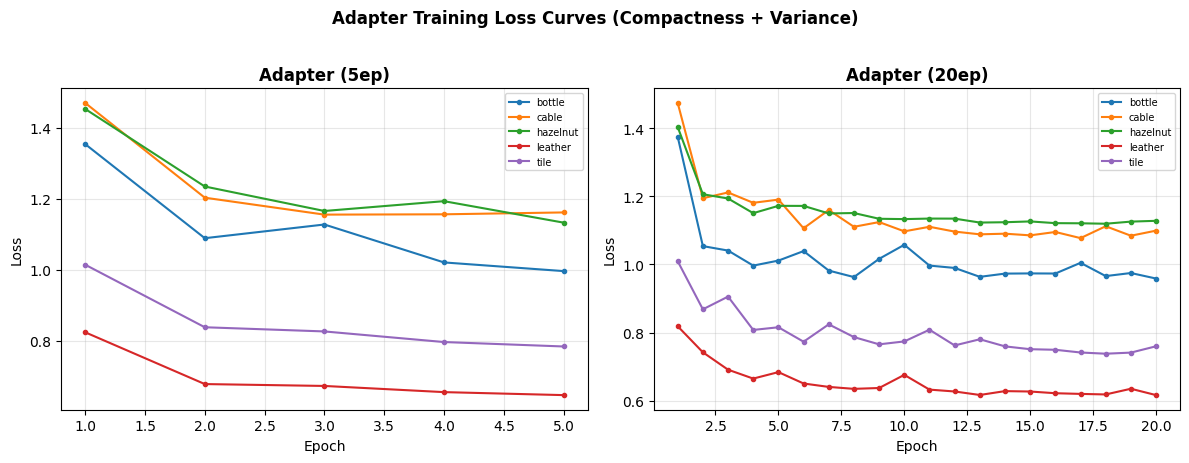


Saved models:
  adapter_bottle_ep20.pt: 3.0 MB
  adapter_bottle_ep5.pt: 3.0 MB
  adapter_cable_ep20.pt: 3.0 MB
  adapter_cable_ep5.pt: 3.0 MB
  adapter_hazelnut_ep20.pt: 3.0 MB
  adapter_hazelnut_ep5.pt: 3.0 MB
  adapter_leather_ep20.pt: 3.0 MB
  adapter_leather_ep5.pt: 3.0 MB
  adapter_tile_ep20.pt: 3.0 MB
  adapter_tile_ep5.pt: 3.0 MB


In [9]:
# -- CELL 8 : Train adapters -------------------------------------------------------

# Load shared frozen DINOv2 backbone (used by all DINOv2 models)
print("Loading frozen DINOv2 backbone...")
dino_backbone = DINOv2Backbone(device=device)

# Train adapters at two regimes
adapter_configs = {
    "Adapter (5ep)":  {"epochs": 5},
    "Adapter (20ep)": {"epochs": 20},
}

adapters = {}      # adapters[config_name][category] = trained adapter
adapter_losses = {}

for cfg_name, params in adapter_configs.items():
    print(f"\n{'#'*65}")
    print(f"  {cfg_name.upper()}")
    print(f"{'#'*65}")
    adapters[cfg_name] = {}
    adapter_losses[cfg_name] = {}

    for cat in CATEGORIES:
        trainer = AdapterTrainer(device=device, lr=1e-3, hidden_dim=384)
        loss_hist, adapter = trainer.train_adapter(
            dino_backbone, cat, epochs=params["epochs"], batch_size=4096)
        adapters[cfg_name][cat] = adapter
        adapter_losses[cfg_name][cat] = loss_hist
        del trainer; torch.cuda.empty_cache(); gc.collect()

# Plot loss curves
n_cfg = len(adapter_configs)
fig, axes = plt.subplots(1, n_cfg, figsize=(6*n_cfg, 4.5))
if n_cfg == 1: axes = [axes]
for ax, (cfg_name, cat_losses) in zip(axes, adapter_losses.items()):
    for cat in CATEGORIES:
        ax.plot(range(1, len(cat_losses[cat]["total"])+1),
                cat_losses[cat]["total"], 'o-', label=cat, markersize=3)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(cfg_name, fontweight="bold"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.suptitle("Adapter Training Loss Curves (Compactness + Variance)", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/content/ckpt3_adapter_losses.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved models:")
for f in sorted(FT_DIR.iterdir()):
    print(f"  {f.name}: {f.stat().st_size/1e6:.1f} MB")

## Four-Way Comparison

In [10]:
# -- CELL 9 : Four-way comparison ---------------------------------------------------

model_names = ["ResNet-50", "DINOv2 Frozen", "Adapter (5ep)", "Adapter (20ep)"]
all_results = {}

for cat in CATEGORIES:
    print(f"\n{'='*60}")
    print(f"  {cat.upper()}")
    print(f"{'='*60}")
    all_results[cat] = {}

    for n_shot in SHOT_COUNTS:
        sl = "Full" if n_shot == -1 else f"{n_shot}-shot"
        n = None if n_shot == -1 else n_shot
        trl, tel = make_loaders(cat, n_shot=n)

        # ResNet-50
        print(f"  >> ResNet-50 | {sl}")
        m = PatchCore("resnet50", device=device, n_shot=n); m.fit(trl)
        all_results[cat].setdefault("ResNet-50",{})[sl] = m.evaluate(tel)
        del m; torch.cuda.empty_cache()

        # DINOv2 Frozen (no adapter)
        print(f"  >> DINOv2 Frozen | {sl}")
        m = PatchCore("dinov2", device=device, n_shot=n, dino_backbone=dino_backbone)
        m.fit(trl)
        all_results[cat].setdefault("DINOv2 Frozen",{})[sl] = m.evaluate(tel)
        del m; torch.cuda.empty_cache()

        # Adapter variants
        for cfg_name in adapter_configs:
            print(f"  >> {cfg_name} | {sl}")
            m = PatchCore("dinov2_adapter", device=device, n_shot=n,
                          dino_backbone=dino_backbone, adapter=adapters[cfg_name][cat])
            m.fit(trl)
            all_results[cat].setdefault(cfg_name,{})[sl] = m.evaluate(tel)
            del m; torch.cuda.empty_cache()

        gc.collect()

print("\nAll experiments complete.")


  BOTTLE
  [bottle] 1-shot | train=1 | test=83
  >> ResNet-50 | 1-shot
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 216MB/s]


  Bank: torch.Size([784, 1536]) | 1 imgs
  AUROC: 0.9937
  >> DINOv2 Frozen | 1-shot
  Bank: torch.Size([256, 768]) | 1 imgs
  AUROC: 1.0000
  >> Adapter (5ep) | 1-shot
  Bank: torch.Size([256, 768]) | 1 imgs
  AUROC: 1.0000
  >> Adapter (20ep) | 1-shot
  Bank: torch.Size([256, 768]) | 1 imgs
  AUROC: 1.0000
  [bottle] 5-shot | train=5 | test=83
  >> ResNet-50 | 5-shot
    Coreset: 3920 -> 980 (25.0%)
  Bank: torch.Size([980, 1536]) | 5 imgs
  AUROC: 0.9984
  >> DINOv2 Frozen | 5-shot
    Coreset: 1280 -> 320 (25.0%)
  Bank: torch.Size([320, 768]) | 5 imgs
  AUROC: 0.9992
  >> Adapter (5ep) | 5-shot
    Coreset: 1280 -> 320 (25.0%)
  Bank: torch.Size([320, 768]) | 5 imgs
  AUROC: 0.9968
  >> Adapter (20ep) | 5-shot
    Coreset: 1280 -> 320 (25.0%)
  Bank: torch.Size([320, 768]) | 5 imgs
  AUROC: 0.9976
  [bottle] 10-shot | train=10 | test=83
  >> ResNet-50 | 10-shot
    Coreset: 7840 -> 784 (10.0%)
  Bank: torch.Size([784, 1536]) | 10 imgs
  AUROC: 0.9984
  >> DINOv2 Frozen | 10-shot
 

In [11]:
# -- CELL 10 : Results tables -------------------------------------------------------
shot_labels = ["1-shot", "5-shot", "10-shot", "Full"]

for cat in CATEGORIES:
    print(f"\n{'='*75}")
    print(f"  {cat.upper()}")
    print(f"{'='*75}")
    rows = [{"N-Shot": sl, **{mn: all_results[cat][mn][sl] for mn in model_names}} for sl in shot_labels]
    print(pd.DataFrame(rows).to_string(index=False, float_format="%.4f"))

print(f"\n{'='*75}")
print(f"  CROSS-CATEGORY AVERAGE")
print(f"{'='*75}")
avg_rows = []
for sl in shot_labels:
    row = {"N-Shot": sl}
    for mn in model_names:
        row[mn] = np.mean([all_results[cat][mn][sl] for cat in CATEGORIES])
    avg_rows.append(row)
df_avg = pd.DataFrame(avg_rows)
print(df_avg.to_string(index=False, float_format="%.4f"))

print("\n  vs Frozen DINOv2:")
for sl in shot_labels:
    fz = np.mean([all_results[cat]["DINOv2 Frozen"][sl] for cat in CATEGORIES])
    parts = []
    for mn in model_names[2:]:
        v = np.mean([all_results[cat][mn][sl] for cat in CATEGORIES])
        parts.append(f"{mn}={v:.4f}({v-fz:+.4f})")
    print(f"    {sl:>8s}: Frozen={fz:.4f} | {' | '.join(parts)}")

df_avg.to_csv("/content/ckpt3_adapter_results.csv", index=False)


  BOTTLE
 N-Shot  ResNet-50  DINOv2 Frozen  Adapter (5ep)  Adapter (20ep)
 1-shot     0.9937         1.0000         1.0000          1.0000
 5-shot     0.9984         0.9992         0.9968          0.9976
10-shot     0.9984         1.0000         0.9976          0.9984
   Full     1.0000         1.0000         1.0000          1.0000

  CABLE
 N-Shot  ResNet-50  DINOv2 Frozen  Adapter (5ep)  Adapter (20ep)
 1-shot     0.7590         0.8885         0.9078          0.9226
 5-shot     0.9297         0.9151         0.9310          0.9288
10-shot     0.8259         0.8996         0.9093          0.9018
   Full     0.9031         0.9108         0.9286          0.9323

  HAZELNUT
 N-Shot  ResNet-50  DINOv2 Frozen  Adapter (5ep)  Adapter (20ep)
 1-shot     0.8239         0.8989         0.9257          0.9171
 5-shot     0.8593         0.9650         0.9582          0.9564
10-shot     0.9175         0.9700         0.9718          0.9686
   Full     1.0000         0.9936         0.9893          0

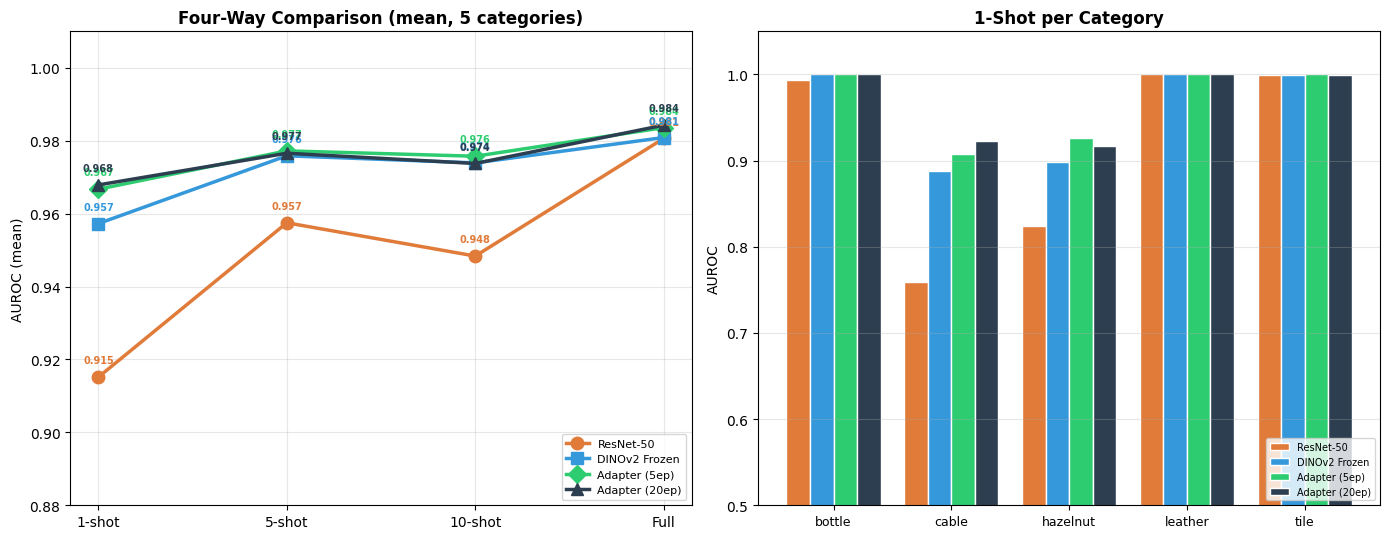

In [12]:
# -- CELL 11 : Figures --------------------------------------------------------------
shot_labels = ["1-shot", "5-shot", "10-shot", "Full"]
colors = {"ResNet-50":"#e07b39", "DINOv2 Frozen":"#3498db",
          "Adapter (5ep)":"#2ecc71", "Adapter (20ep)":"#2c3e50"}
markers = {"ResNet-50":"o", "DINOv2 Frozen":"s", "Adapter (5ep)":"D", "Adapter (20ep)":"^"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

x = range(len(shot_labels))
for mn in model_names:
    vals = [np.mean([all_results[cat][mn][sl] for cat in CATEGORIES]) for sl in shot_labels]
    axes[0].plot(x, vals, f'{markers[mn]}-', color=colors[mn], linewidth=2.5, markersize=9, label=mn)
    for i, v in enumerate(vals):
        axes[0].annotate(f"{v:.3f}", (i,v), textcoords="offset points",
                         xytext=(0,10), ha="center", fontsize=7, color=colors[mn], fontweight="bold")

axes[0].set_xticks(x); axes[0].set_xticklabels(shot_labels)
axes[0].set_ylim(0.88, 1.01); axes[0].set_ylabel("AUROC (mean)")
axes[0].set_title(f"Four-Way Comparison (mean, {len(CATEGORIES)} categories)", fontweight="bold")
axes[0].legend(loc="lower right", fontsize=8); axes[0].grid(alpha=0.3)

bw = 0.2; xc = np.arange(len(CATEGORIES))
for mi, mn in enumerate(model_names):
    vals = [all_results[cat][mn]["1-shot"] for cat in CATEGORIES]
    axes[1].bar(xc + (mi-1.5)*bw, vals, bw, label=mn, color=colors[mn], edgecolor="white")
axes[1].set_xticks(xc); axes[1].set_xticklabels(CATEGORIES, fontsize=9)
axes[1].set_ylim(0.5, 1.05); axes[1].set_ylabel("AUROC")
axes[1].set_title("1-Shot per Category", fontweight="bold")
axes[1].legend(loc="lower right", fontsize=7); axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("/content/ckpt3_adapter_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# -- CELL 12 : Final summary -------------------------------------------------------
print("="*65)
print("  FINAL SUMMARY")
print("="*65)
print(f"\n  Categories: {CATEGORIES}")
print(f"  Models: {model_names}")
print(f"  Experiments: {len(CATEGORIES)*len(model_names)*len(shot_labels)}")

print("\n  Cross-category averages:")
for sl in shot_labels:
    print(f"\n    {sl}:")
    for mn in model_names:
        avg = np.mean([all_results[cat][mn][sl] for cat in CATEGORIES])
        print(f"      {mn:>22s}: {avg:.4f}")

print("\n  Adapter details:")
print("    Architecture: 768 -> 384 -> 384 -> 768 + residual")
print("    Parameters: ~1.18M (vs 21M for backbone FT, vs 86M total)")
print("    Loss: compactness + variance preservation")
print("    Training: on cached features (no backbone backprop)")
print("    Residual init: adapter output starts as identity")

print("\n  Key findings:")
print("    1. DINOv2 Frozen B12 > ResNet-50 in few-shot (ablation study)")
print("    2. Backbone fine-tuning fails (21M params, 209 images = over-adaptation)")
print("    3. Lightweight adapter results shown above")
print("="*65)

  FINAL SUMMARY

  Categories: ['bottle', 'cable', 'hazelnut', 'leather', 'tile']
  Models: ['ResNet-50', 'DINOv2 Frozen', 'Adapter (5ep)', 'Adapter (20ep)']
  Experiments: 80

  Cross-category averages:

    1-shot:
                   ResNet-50: 0.9152
               DINOv2 Frozen: 0.9573
               Adapter (5ep): 0.9667
              Adapter (20ep): 0.9679

    5-shot:
                   ResNet-50: 0.9575
               DINOv2 Frozen: 0.9759
               Adapter (5ep): 0.9772
              Adapter (20ep): 0.9766

    10-shot:
                   ResNet-50: 0.9484
               DINOv2 Frozen: 0.9739
               Adapter (5ep): 0.9757
              Adapter (20ep): 0.9738

    Full:
                   ResNet-50: 0.9806
               DINOv2 Frozen: 0.9809
               Adapter (5ep): 0.9836
              Adapter (20ep): 0.9843

  Adapter details:
    Architecture: 768 -> 384 -> 384 -> 768 + residual
    Parameters: ~1.18M (vs 21M for backbone FT, vs 86M total)
    Loss: compact